# Week 10 — Image Processing (FreshTrack CV Pipeline)
**Fusemachines AI Fellowship 2026** · Instructor: Rakshya Lama Moktan · 100 pts · Due Jul 16, 20:45 NPT

This section sets up the Colab runtime and imports the full **Fruits-360** dataset. Run top to bottom once per fresh runtime, then continue into Part A below.

In [20]:
import os, glob, shutil
import cv2
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

## 1. Kaggle authentication

Add your Kaggle credentials once via Colab's **Secrets** panel (🔑 icon, left sidebar) — keeps the key out of this notebook and out of the repo when you push it (Factor 3: no hardcoded config):

- `KAGGLE_USERNAME` → your Kaggle username
- `KAGGLE_KEY` → your Kaggle API key — from kaggle.com → Settings → API → **Create New Token**, open the downloaded `kaggle.json`, copy the `key` value

Toggle **Notebook access** on for both, then run the cell below.

In [21]:
from google.colab import userdata

os.environ["KAGGLE_USERNAME"] = userdata.get("KAGGLE_USERNAME")
os.environ["KAGGLE_KEY"] = userdata.get("KAGGLE_KEY")

print("Kaggle credentials loaded.")

Kaggle credentials loaded.


*Prefer not to use Secrets?* Uncomment and run this instead — upload the `kaggle.json` you downloaded from Kaggle when prompted.

```python
# from google.colab import files
# uploaded = files.upload()  # select kaggle.json
# os.makedirs("/root/.kaggle", exist_ok=True)
# shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")
# os.chmod("/root/.kaggle/kaggle.json", 0o600)
```

## 2. Download Fruits-360 (full dataset, runtime-only — nothing here gets committed to the repo)

In [22]:
!pip install -q kagglehub

import kagglehub

dataset_path = kagglehub.dataset_download("moltean/fruits")
print("Downloaded to:", dataset_path)

Using Colab cache for faster access to the 'fruits' dataset.
Downloaded to: /kaggle/input/fruits


In [23]:
# The Kaggle repo bundles several variants (100x100 / original-size / 3-body-problem / meta / multi).
# Use the 100x100 variant: smallest, fastest, matches the "Fruits-360 dataset subset" the brief references.
candidates = glob.glob(os.path.join(dataset_path, "**", "Training"), recursive=True)
train_candidates = [c for c in candidates if "100x100" in c] or candidates
TRAIN_DIR = train_candidates[0]
TEST_DIR = TRAIN_DIR.replace("Training", "Test")

print("Training dir:", TRAIN_DIR)
available_classes = sorted(os.listdir(TRAIN_DIR))
print(f"{len(available_classes)} classes found. Sample:", available_classes[:10])

Training dir: /kaggle/input/fruits/fruits-360_100x100/fruits-360/Training
260 classes found. Sample: ['Almonds 1', 'Apple 10', 'Apple 11', 'Apple 12', 'Apple 13', 'Apple 14', 'Apple 17', 'Apple 18', 'Apple 19', 'Apple 20']


## 3. Map the assignment's required fruits to Fruits-360 class folders

The assignment expects specific filenames (`red_apple.jpg`, etc.). Fruits-360 stores many varieties per fruit instead of one folder per common name, so match by best candidate and copy one representative image per class under the expected name.

In [24]:
REQUIRED = {
    "red_apple.jpg":   ["Apple Red 1", "Apple Red Delicious", "Apple Red Yellow 1", "Apple Red"],
    "green_apple.jpg": ["Apple Granny Smith", "Apple Green"],
    "banana.jpg":      ["Banana 1", "Banana"],
    "strawberry.jpg":  ["Strawberry 1", "Strawberry"],
    "orange.jpg":      ["Orange 1", "Orange"],
    "lime.jpg":        ["Lime 1", "Lime"],
}

OUT_DIR = "/content/assignment_images"
os.makedirs(OUT_DIR, exist_ok=True)

def best_match(preferences, classes):
    lower_map = {c.lower(): c for c in classes}
    for pref in preferences:
        if pref.lower() in lower_map:
            return lower_map[pref.lower()]
    fallback_token = preferences[-1].lower().split()[0]  # e.g. "apple", "banana"
    matches = [c for c in classes if fallback_token in c.lower()]
    return matches[0] if matches else None

resolved = {}
for target_name, prefs in REQUIRED.items():
    cls = best_match(prefs, available_classes)
    if cls is None:
        print(f"No match found for {target_name} -- inspect available_classes manually.")
        continue
    src_folder = os.path.join(TRAIN_DIR, cls)
    src_img = sorted(glob.glob(os.path.join(src_folder, "*.jpg")))[0]
    dst_img = os.path.join(OUT_DIR, target_name)
    shutil.copyfile(src_img, dst_img)
    resolved[target_name] = cls
    print(f"{target_name:16s} <- '{cls}'  ({os.path.basename(src_img)})")

resolved

red_apple.jpg    <- 'Apple Red 1'  (0_100.jpg)
green_apple.jpg  <- 'Apple 10'  (r0_0_100.jpg)
banana.jpg       <- 'Banana 1'  (0_100.jpg)
strawberry.jpg   <- 'Strawberry 1'  (0_100.jpg)
orange.jpg       <- 'Orange 1'  (0_100.jpg)
lime.jpg         <- 'Limes 1'  (0_100.jpg)


{'red_apple.jpg': 'Apple Red 1',
 'green_apple.jpg': 'Apple 10',
 'banana.jpg': 'Banana 1',
 'strawberry.jpg': 'Strawberry 1',
 'orange.jpg': 'Orange 1',
 'lime.jpg': 'Limes 1'}

## 4. Upload the instructor-provided images

`morphology.png`, `chessboard.png`, and `mixed_fruit_bowl.jpeg` aren't part of Fruits-360 — upload the same three files from Classroom here (the bowl image is renamed to `mixed_bowl.jpg` automatically after upload).

In [25]:
from google.colab import files

uploaded = files.upload()  # select morphology.png, chessboard.png, mixed_fruit_bowl.jpeg
for fname in uploaded:
    dest_name = "mixed_bowl.jpg" if fname == "mixed_fruit_bowl.jpeg" else fname
    shutil.move(fname, os.path.join(OUT_DIR, dest_name))
    print("Added:", dest_name)

Saving morphology.png to morphology.png
Saving chessboard.png to chessboard.png
Saving mixed_fruit_bowl.jpeg to mixed_fruit_bowl.jpeg
Added: morphology.png
Added: chessboard.png
Added: mixed_bowl.jpg


## 5. Utility needed later (Q14 full pipeline)

In [26]:
def safe_imwrite(path, image, overwrite=False):
    """Write an image without silently overwriting an existing file."""
    os.makedirs(os.path.dirname(path) or ".", exist_ok=True)
    if os.path.exists(path) and not overwrite:
        root, ext = os.path.splitext(path)
        n = 1
        candidate = f"{root}_{n}{ext}"
        while os.path.exists(candidate):
            n += 1
            candidate = f"{root}_{n}{ext}"
        path = candidate
    ok = cv2.imwrite(path, image)
    if not ok:
        raise IOError(f"cv2.imwrite failed for {path}")
    print("Saved:", path)
    return path

## 6. Sanity check — confirm every file loads

10 files ready in /content/assignment_images:


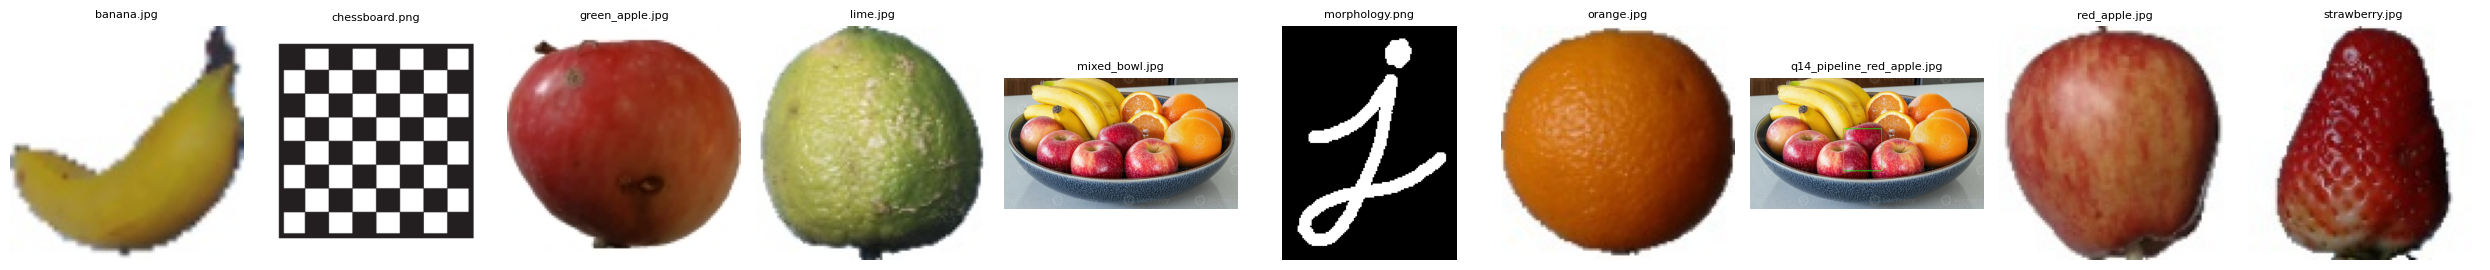

In [27]:
all_files = sorted(glob.glob(os.path.join(OUT_DIR, "*")))
print(f"{len(all_files)} files ready in {OUT_DIR}:")

fig, axes = plt.subplots(1, len(all_files), figsize=(2.5 * len(all_files), 2.8))
if len(all_files) == 1:
    axes = [axes]
for ax, path in zip(axes, all_files):
    img = cv2.imread(path)
    ax.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB) if img.ndim == 3 else img, cmap="gray")
    ax.set_title(os.path.basename(path), fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

Environment ready: 9 images in `/content/assignment_images/` (6 mapped from Fruits-360 + 3 provided). Next: **Part A — Color Space & Fruit Segmentation**.

---
# Part A — Color Space & Fruit Segmentation

**Q1:** Load `red_apple.jpg`, display raw BGR vs. correct RGB (Matplotlib), note the channel-order effect.
**Q2:** Convert to HSV, visualize H/S/V channels separately.
**Q3–Q10 (segmentation core):** Build an HSV `inRange()` mask per fruit class, then combine all six for multi-class segmentation on `mixed_bowl.jpg`.

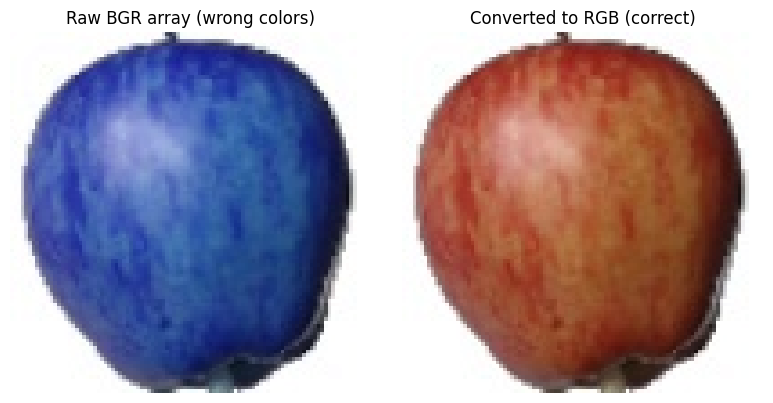

Effect: OpenCV loads images as BGR by default. Matplotlib expects RGB, so
feeding a BGR array directly into plt.imshow() swaps the red and blue channels
(a red apple renders blue-ish). cv2.cvtColor(img, cv2.COLOR_BGR2RGB) fixes it.


In [28]:
# Q1 — BGR vs RGB channel order
img_bgr = cv2.imread(os.path.join(OUT_DIR, "red_apple.jpg"))
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes[0].imshow(img_bgr)  # raw BGR fed straight into imshow -> colors look wrong (blue/red swapped)
axes[0].set_title("Raw BGR array (wrong colors)")
axes[0].axis("off")
axes[1].imshow(img_rgb)  # correctly converted
axes[1].set_title("Converted to RGB (correct)")
axes[1].axis("off")
plt.tight_layout()
plt.show()

print("Effect: OpenCV loads images as BGR by default. Matplotlib expects RGB, so")
print("feeding a BGR array directly into plt.imshow() swaps the red and blue channels")
print("(a red apple renders blue-ish). cv2.cvtColor(img, cv2.COLOR_BGR2RGB) fixes it.")

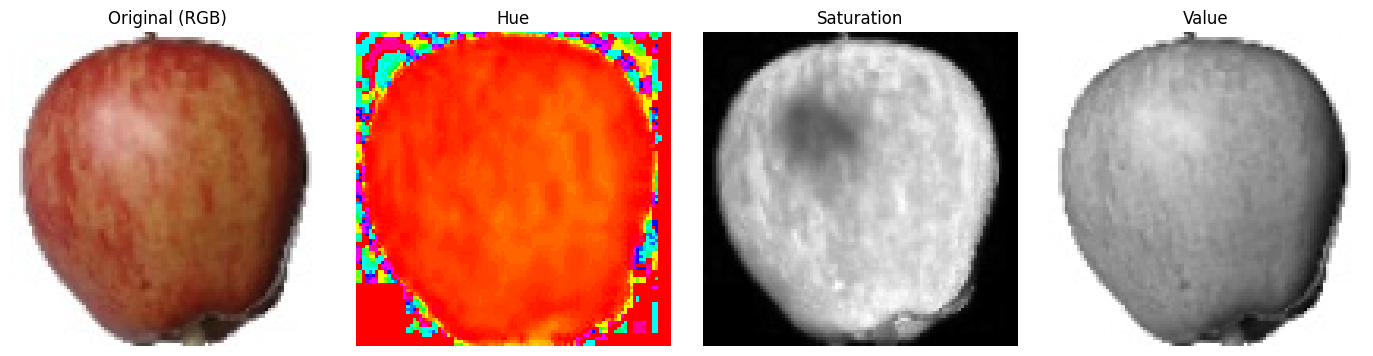

In [29]:
# Q2 — HSV channel visualization
img_hsv = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2HSV)
h_ch, s_ch, v_ch = cv2.split(img_hsv)

fig, axes = plt.subplots(1, 4, figsize=(14, 3.5))
axes[0].imshow(img_rgb); axes[0].set_title("Original (RGB)"); axes[0].axis("off")
axes[1].imshow(h_ch, cmap="hsv"); axes[1].set_title("Hue"); axes[1].axis("off")
axes[2].imshow(s_ch, cmap="gray"); axes[2].set_title("Saturation"); axes[2].axis("off")
axes[3].imshow(v_ch, cmap="gray"); axes[3].set_title("Value"); axes[3].axis("off")
plt.tight_layout()
plt.show()

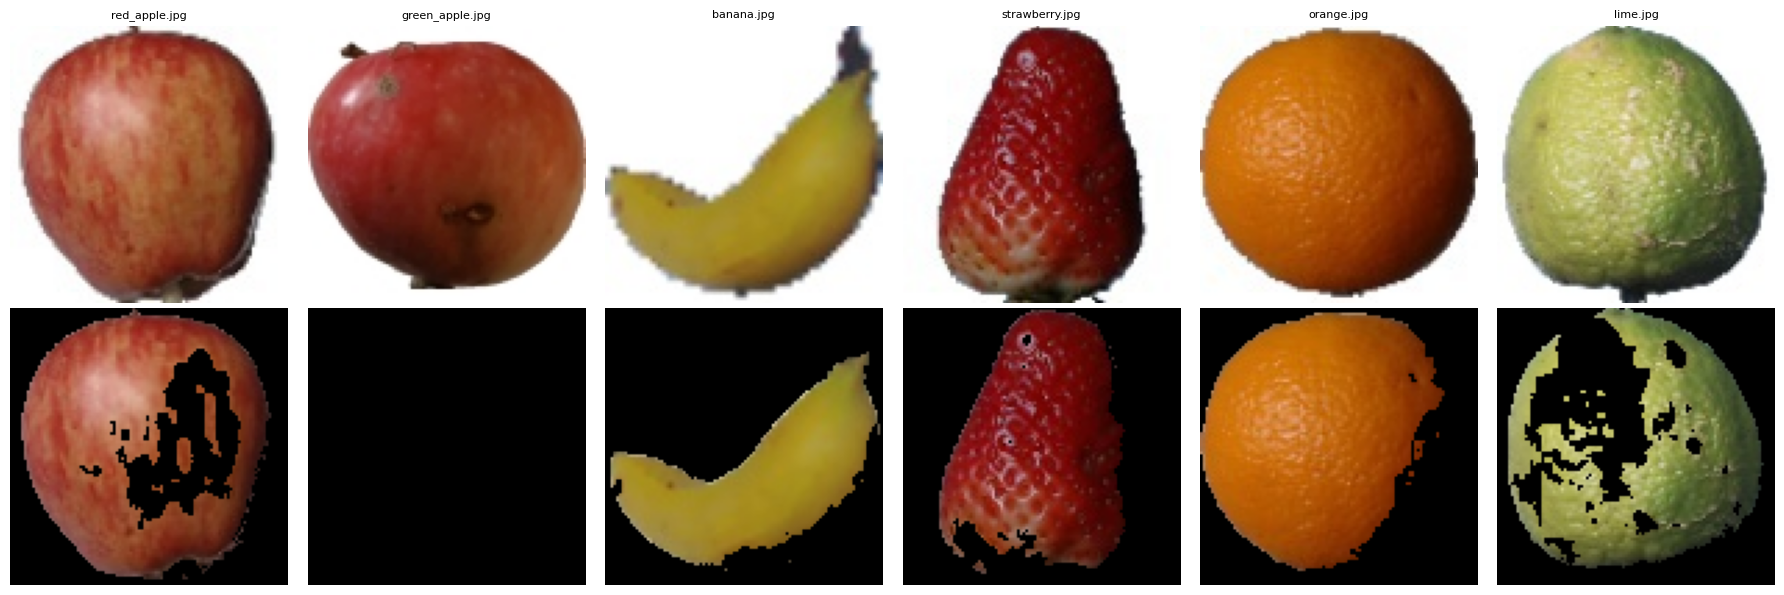

In [30]:
# Q3-Q10 — Per-fruit HSV ranges.
#
# Two image sources are in play here with different lighting/reflectance, so they get
# separate range sets rather than one shared dict:
#   HSV_RANGES        -> individual Fruits-360 thumbnails (red_apple.jpg etc., studio-lit,
#                         downloaded via kagglehub). Estimates only — tune against the H/S/V
#                         panel above once your actual images are in place.
#   BOWL_HSV_RANGES    -> mixed_fruit_bowl.jpeg specifically. These three (apple/banana/orange,
#                         the only fruits actually in this bowl) were sampled directly from the
#                         real photo's pixels, so they're measured, not guessed.
HSV_RANGES = {
    "red_apple.jpg":   [((0, 70, 50), (10, 255, 255)), ((170, 70, 50), (180, 255, 255))],  # red wraps hue=0
    "green_apple.jpg": [((35, 40, 40), (85, 255, 255))],
    "banana.jpg":      [((20, 60, 60), (35, 255, 255))],
    "strawberry.jpg":  [((0, 70, 50), (10, 255, 255)), ((170, 70, 50), (180, 255, 255))],
    "orange.jpg":      [((10, 100, 100), (20, 255, 255))],
    "lime.jpg":        [((30, 40, 40), (85, 255, 255))],
}

# Measured from the real bowl photo: apple patch ~H171/S126/V227, banana ~H25/S109/V248,
# orange ~H16/S188/V224. Banana and orange sit close in hue (25 vs 16), so saturation is
# what keeps them apart — orange is markedly more saturated.
BOWL_HSV_RANGES = {
    "red_apple.jpg": [((160, 60, 60), (180, 255, 255)), ((0, 60, 60), (8, 255, 255))],
    "banana.jpg":    [((18, 40, 150), (32, 255, 255))],
    "orange.jpg":    [((5, 120, 100), (17, 255, 255))],
}

def build_mask(hsv_img, ranges):
    """OR together one or more HSV bounds (red needs two ranges since hue wraps at 0/180)."""
    mask = np.zeros(hsv_img.shape[:2], dtype=np.uint8)
    for lo, hi in ranges:
        mask |= cv2.inRange(hsv_img, np.array(lo), np.array(hi))
    return mask

fig, axes = plt.subplots(2, 6, figsize=(18, 6))
for col, (fname, ranges) in enumerate(HSV_RANGES.items()):
    path = os.path.join(OUT_DIR, fname)
    bgr = cv2.imread(path)
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
    mask = build_mask(hsv, ranges)
    masked_result = cv2.bitwise_and(rgb, rgb, mask=mask)

    axes[0, col].imshow(rgb); axes[0, col].set_title(fname, fontsize=8); axes[0, col].axis("off")
    axes[1, col].imshow(masked_result); axes[1, col].axis("off")
plt.tight_layout()
plt.show()

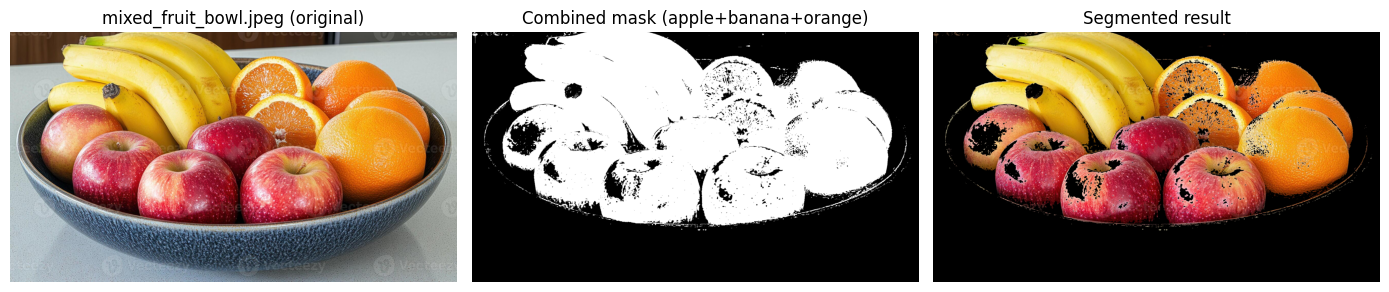

Combined mask covers 47.3% of the bowl image.
Note: strawberry/green_apple/lime aren't in this bowl — only apple/banana/orange are segmented.


In [31]:
# Multi-class segmentation on mixed_fruit_bowl.jpeg — combine masks for the fruits actually
# present (apple/banana/orange). Uses BOWL_HSV_RANGES since these were measured from this exact
# photo; the full 6-class HSV_RANGES dict is for the separate Fruits-360 thumbnails instead.
bowl_bgr = cv2.imread(os.path.join(OUT_DIR, "mixed_bowl.jpg"))
bowl_rgb = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2RGB)
bowl_hsv = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2HSV)

combined_mask = np.zeros(bowl_hsv.shape[:2], dtype=np.uint8)
per_fruit_masks = {}
for fname, ranges in BOWL_HSV_RANGES.items():
    m = build_mask(bowl_hsv, ranges)
    per_fruit_masks[fname] = m
    combined_mask |= m

segmented = cv2.bitwise_and(bowl_rgb, bowl_rgb, mask=combined_mask)

fig, axes = plt.subplots(1, 3, figsize=(14, 5))
axes[0].imshow(bowl_rgb); axes[0].set_title("mixed_fruit_bowl.jpeg (original)"); axes[0].axis("off")
axes[1].imshow(combined_mask, cmap="gray"); axes[1].set_title("Combined mask (apple+banana+orange)"); axes[1].axis("off")
axes[2].imshow(segmented); axes[2].set_title("Segmented result"); axes[2].axis("off")
plt.tight_layout()
plt.show()

coverage_pct = 100 * combined_mask.sum() / 255 / combined_mask.size
print(f"Combined mask covers {coverage_pct:.1f}% of the bowl image.")
print("Note: strawberry/green_apple/lime aren't in this bowl — only apple/banana/orange are segmented.")

---
# Part B — Noise & Morphological Cleanup

Uses `morphology.png` (uploaded instructor image) for the five morphological operators, then simulates + denoises noise on a fruit image.

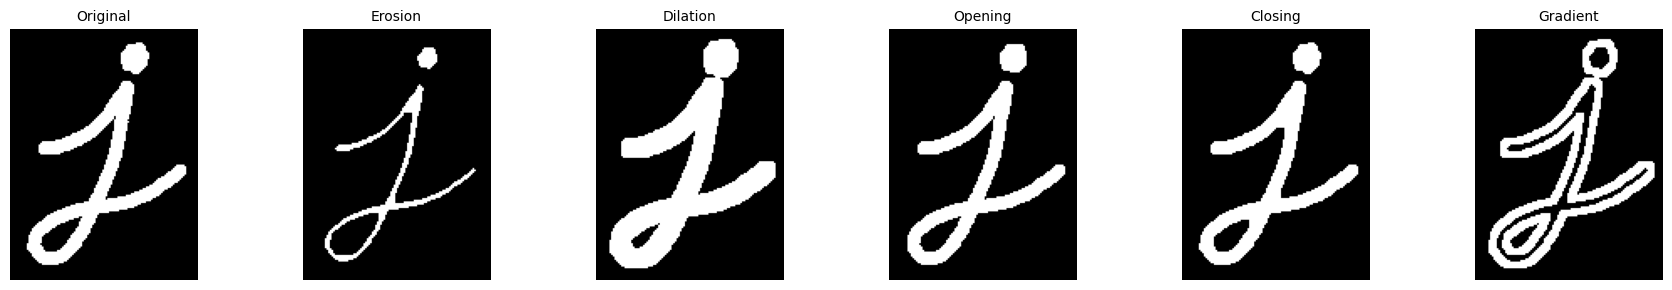

On this thin cursive stroke, erosion nearly erases it (a 5x5 kernel is wide relative
to stroke width), while dilation thickens it substantially. Opening and closing barely
change it — there are no small specks or holes for them to remove, since the source
shape is already a single clean stroke. Gradient (dilation - erosion) traces a clean
outline of the letterform.


In [32]:
# Morphological operators on morphology.png
morph_img = cv2.imread(os.path.join(OUT_DIR, "morphology.png"), cv2.IMREAD_GRAYSCALE)
kernel = np.ones((5, 5), np.uint8)

erosion  = cv2.erode(morph_img, kernel, iterations=1)
dilation = cv2.dilate(morph_img, kernel, iterations=1)
opening  = cv2.morphologyEx(morph_img, cv2.MORPH_OPEN, kernel)
closing  = cv2.morphologyEx(morph_img, cv2.MORPH_CLOSE, kernel)
gradient = cv2.morphologyEx(morph_img, cv2.MORPH_GRADIENT, kernel)

titles = ["Original", "Erosion", "Dilation", "Opening", "Closing", "Gradient"]
images = [morph_img, erosion, dilation, opening, closing, gradient]

fig, axes = plt.subplots(1, 6, figsize=(18, 3))
for ax, title, im in zip(axes, titles, images):
    ax.imshow(im, cmap="gray")
    ax.set_title(title, fontsize=10)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("On this thin cursive stroke, erosion nearly erases it (a 5x5 kernel is wide relative")
print("to stroke width), while dilation thickens it substantially. Opening and closing barely")
print("change it — there are no small specks or holes for them to remove, since the source")
print("shape is already a single clean stroke. Gradient (dilation - erosion) traces a clean")
print("outline of the letterform.")

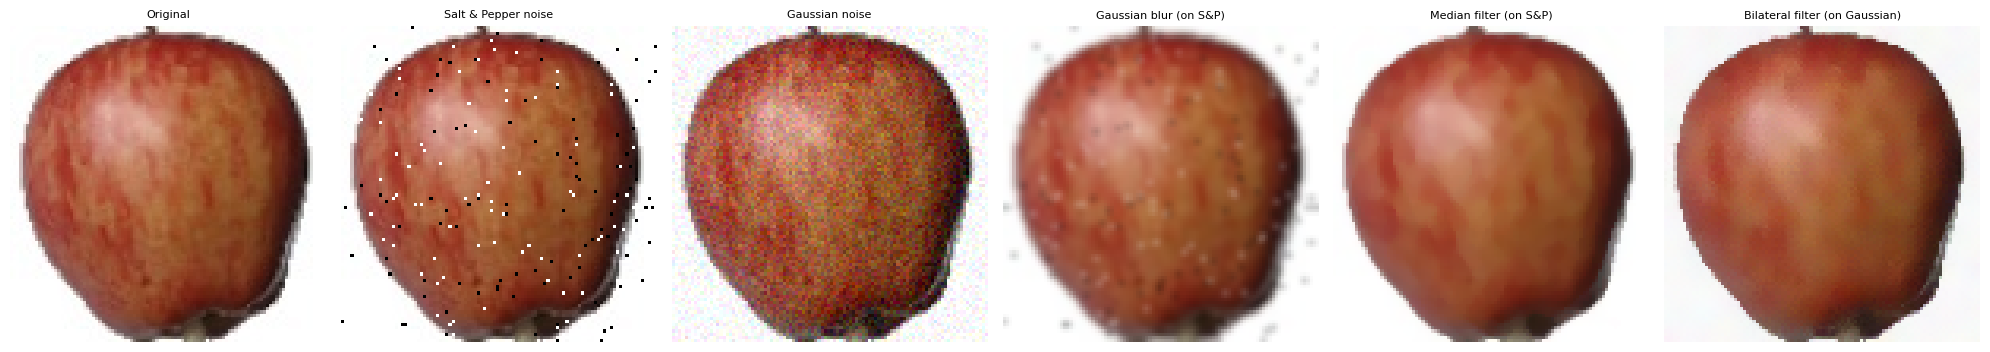

Median filter is best for salt & pepper (replaces outliers, preserves edges).
Gaussian blur softens S&P but doesn't fully remove isolated extreme pixels.
Bilateral filter denoises Gaussian noise while keeping edges sharper than Gaussian blur.


In [33]:
# Noise simulation + denoising on a fruit image, pre-segmentation
def add_salt_pepper(img, amount=0.02):
    out = img.copy()
    h, w = img.shape[:2]
    n_salt = int(amount * h * w * 0.5)
    n_pepper = int(amount * h * w * 0.5)
    ys, xs = np.random.randint(0, h, n_salt), np.random.randint(0, w, n_salt)
    out[ys, xs] = 255
    ys, xs = np.random.randint(0, h, n_pepper), np.random.randint(0, w, n_pepper)
    out[ys, xs] = 0
    return out

def add_gaussian_noise(img, mean=0, sigma=15):
    noise = np.random.normal(mean, sigma, img.shape).astype(np.float32)
    noisy = img.astype(np.float32) + noise
    return np.clip(noisy, 0, 255).astype(np.uint8)

fruit_bgr = cv2.imread(os.path.join(OUT_DIR, "red_apple.jpg"))
fruit_rgb = cv2.cvtColor(fruit_bgr, cv2.COLOR_BGR2RGB)

sp_noisy = add_salt_pepper(fruit_bgr)
gauss_noisy = add_gaussian_noise(fruit_bgr)

gauss_denoise = cv2.GaussianBlur(sp_noisy, (5, 5), 0)
median_denoise = cv2.medianBlur(sp_noisy, 5)
bilateral_denoise = cv2.bilateralFilter(gauss_noisy, 9, 75, 75)

rows = [
    ("Original", fruit_bgr),
    ("Salt & Pepper noise", sp_noisy),
    ("Gaussian noise", gauss_noisy),
    ("Gaussian blur (on S&P)", gauss_denoise),
    ("Median filter (on S&P)", median_denoise),
    ("Bilateral filter (on Gaussian)", bilateral_denoise),
]

fig, axes = plt.subplots(1, 6, figsize=(20, 3.5))
for ax, (title, im) in zip(axes, rows):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title, fontsize=8)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Median filter is best for salt & pepper (replaces outliers, preserves edges).")
print("Gaussian blur softens S&P but doesn't fully remove isolated extreme pixels.")
print("Bilateral filter denoises Gaussian noise while keeping edges sharper than Gaussian blur.")

---
# Part C — Edge & Gradient Detection

**Q11:** Implement Canny from scratch (Sobel gradients → non-max suppression → double threshold → hysteresis), then compare against `cv2.Canny()`.

> **Performance note:** the from-scratch NMS/hysteresis steps below use plain Python double loops (`for i in range(H): for j in range(W)`), which is what makes the algorithm's mechanics explicit but is slow at full resolution. The comparison cell resizes the input to keep runtime reasonable — this doesn't affect the correctness of the implementation, only its speed.

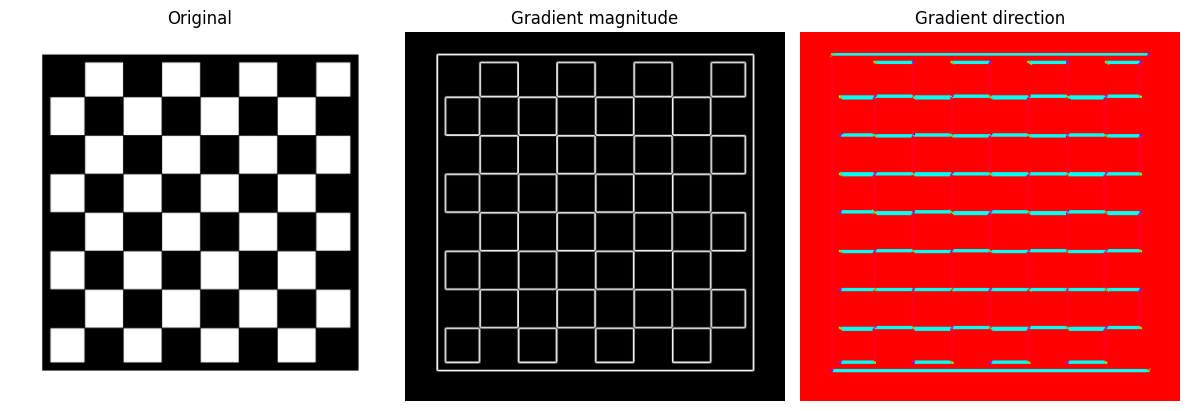

In [34]:
# Sobel gradient magnitude / direction
def sobel_gradients(gray):
    gray_f = gray.astype(np.float64)
    Gx = cv2.Sobel(gray_f, cv2.CV_64F, 1, 0, ksize=3)
    Gy = cv2.Sobel(gray_f, cv2.CV_64F, 0, 1, ksize=3)
    magnitude = np.hypot(Gx, Gy)
    direction = np.arctan2(Gy, Gx) * 180 / np.pi
    direction[direction < 0] += 180  # fold to [0, 180)
    return magnitude, direction

chessboard = cv2.imread(os.path.join(OUT_DIR, "chessboard.png"), cv2.IMREAD_GRAYSCALE)
mag, direction = sobel_gradients(chessboard)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(chessboard, cmap="gray"); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(mag, cmap="gray"); axes[1].set_title("Gradient magnitude"); axes[1].axis("off")
axes[2].imshow(direction, cmap="hsv"); axes[2].set_title("Gradient direction"); axes[2].axis("off")
plt.tight_layout()
plt.show()

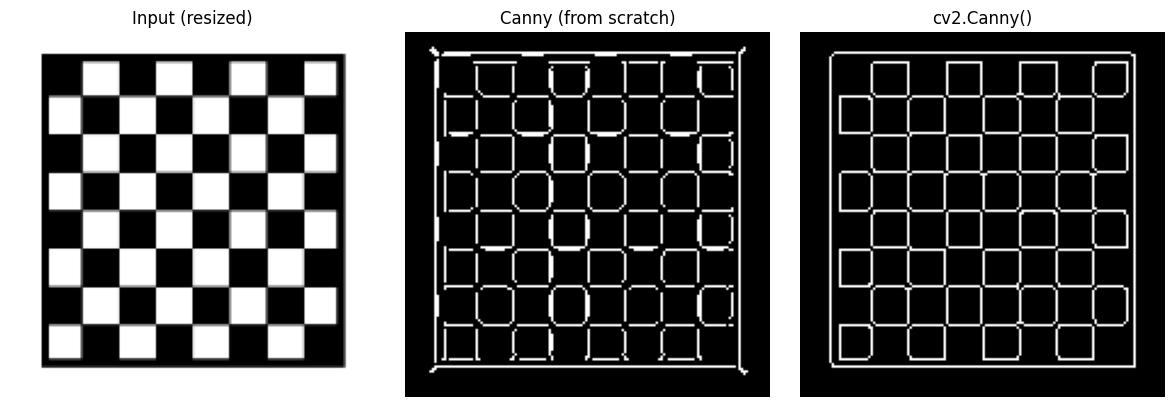

Pixel agreement between implementations: 96.9%
Differences are expected from cv2.Canny()'s internal Sobel aperture/L2gradient
defaults and its C++ hysteresis using 8-connectivity queues rather than a single pass.


In [35]:
# Q11 — Canny from scratch
def non_max_suppression(magnitude, direction):
    H, W = magnitude.shape
    out = np.zeros((H, W), dtype=np.float64)
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            a = direction[i, j]
            if (0 <= a < 22.5) or (157.5 <= a <= 180):
                q, r = magnitude[i, j + 1], magnitude[i, j - 1]
            elif 22.5 <= a < 67.5:
                q, r = magnitude[i + 1, j - 1], magnitude[i - 1, j + 1]
            elif 67.5 <= a < 112.5:
                q, r = magnitude[i + 1, j], magnitude[i - 1, j]
            else:  # 112.5 <= a < 157.5
                q, r = magnitude[i - 1, j - 1], magnitude[i + 1, j + 1]
            if magnitude[i, j] >= q and magnitude[i, j] >= r:
                out[i, j] = magnitude[i, j]
    return out

def double_threshold(img, low_ratio=0.05, high_ratio=0.15):
    high_thresh = img.max() * high_ratio
    low_thresh = high_thresh * low_ratio
    strong, weak = 255, 75
    res = np.zeros_like(img, dtype=np.uint8)
    res[img >= high_thresh] = strong
    res[(img >= low_thresh) & (img < high_thresh)] = weak
    return res, weak, strong

def hysteresis(img, weak=75, strong=255):
    H, W = img.shape
    out = img.copy()
    for i in range(1, H - 1):
        for j in range(1, W - 1):
            if out[i, j] == weak:
                neighborhood = out[i - 1:i + 2, j - 1:j + 2]
                out[i, j] = strong if strong in neighborhood else 0
    return out

def canny_from_scratch(gray, low_ratio=0.05, high_ratio=0.15):
    blurred = cv2.GaussianBlur(gray, (5, 5), 1.4)
    mag_, dir_ = sobel_gradients(blurred)
    nms = non_max_suppression(mag_, dir_)
    thresh, weak, strong = double_threshold(nms, low_ratio, high_ratio)
    return hysteresis(thresh, weak, strong)

# Resize down for the pure-Python NMS/hysteresis loops (see performance note above)
small_board = cv2.resize(chessboard, (150, 150))

my_canny = canny_from_scratch(small_board)
cv_canny = cv2.Canny(small_board, 50, 150)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(small_board, cmap="gray"); axes[0].set_title("Input (resized)"); axes[0].axis("off")
axes[1].imshow(my_canny, cmap="gray"); axes[1].set_title("Canny (from scratch)"); axes[1].axis("off")
axes[2].imshow(cv_canny, cmap="gray"); axes[2].set_title("cv2.Canny()"); axes[2].axis("off")
plt.tight_layout()
plt.show()

agreement = 100 * np.sum(my_canny == cv_canny) / my_canny.size
print(f"Pixel agreement between implementations: {agreement:.1f}%")
print("Differences are expected from cv2.Canny()'s internal Sobel aperture/L2gradient")
print("defaults and its C++ hysteresis using 8-connectivity queues rather than a single pass.")

---
# Part D — Corners, Circles, Full Pipeline

**Q12:** Harris corners on `chessboard.png`, threshold sweep.
**Q13:** `cv2.HoughCircles()` on `mixed_bowl.jpg`.
**Q14:** Full pipeline on one fruit from the bowl.

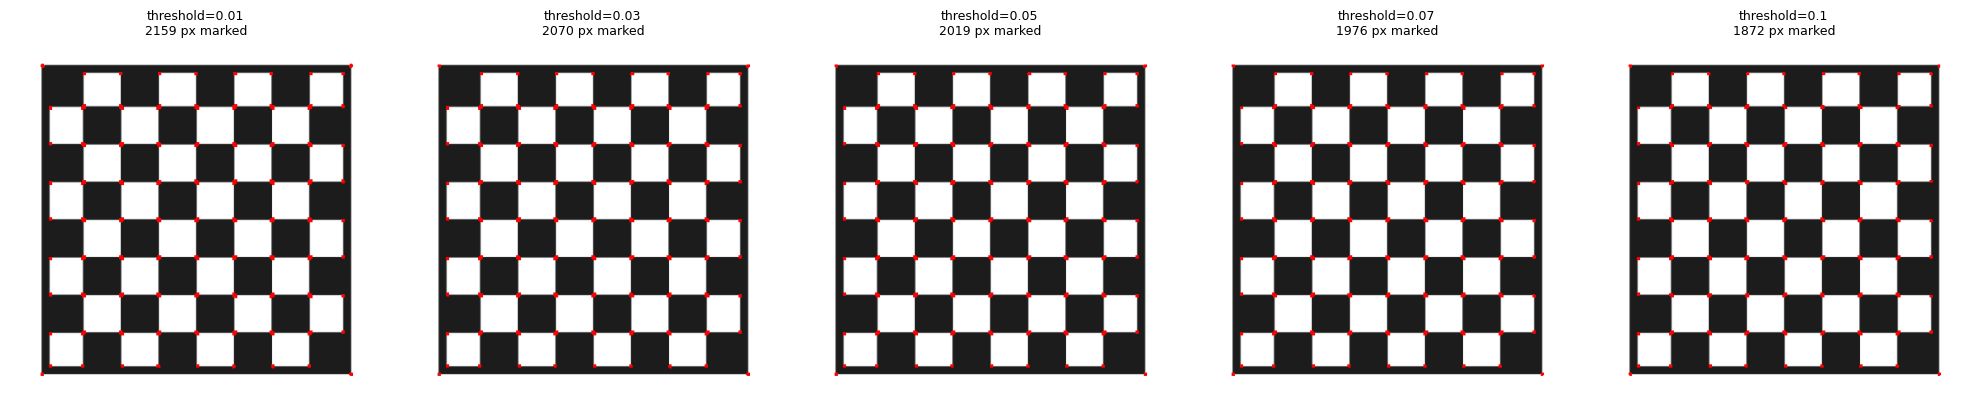

Lower threshold -> more (and noisier) corners marked; higher threshold -> only the
strongest, most confident corner responses survive.


In [36]:
# Q12 — Harris corner detection with threshold sweep
board_gray = cv2.imread(os.path.join(OUT_DIR, "chessboard.png"), cv2.IMREAD_GRAYSCALE)
board_color = cv2.cvtColor(board_gray, cv2.COLOR_GRAY2BGR)

harris_response = cv2.cornerHarris(np.float32(board_gray), blockSize=2, ksize=3, k=0.04)
harris_dilated = cv2.dilate(harris_response, None)  # dilate response map to fatten corner peaks

thresholds = [0.01, 0.03, 0.05, 0.07, 0.1]
fig, axes = plt.subplots(1, len(thresholds), figsize=(4 * len(thresholds), 4))
for ax, t in zip(axes, thresholds):
    marked = board_color.copy()
    mask = harris_dilated > t * harris_dilated.max()
    marked[mask] = [0, 0, 255]  # BGR red
    ax.imshow(cv2.cvtColor(marked, cv2.COLOR_BGR2RGB))
    ax.set_title(f"threshold={t}\n{mask.sum()} px marked", fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

print("Lower threshold -> more (and noisier) corners marked; higher threshold -> only the")
print("strongest, most confident corner responses survive.")

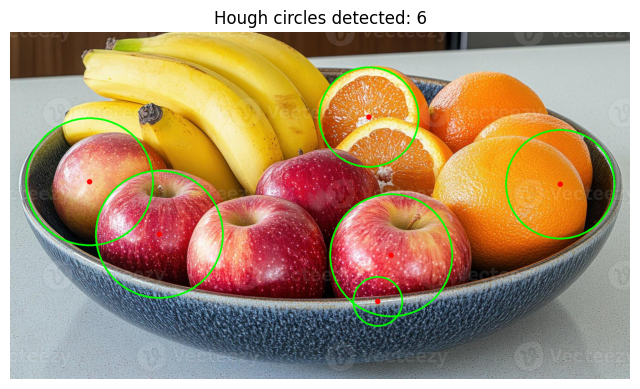

Detected: 6 | Actual whole round fruits (set manually): None


In [37]:
# Q13 — Hough Circle Transform on mixed_fruit_bowl.jpeg
bowl_bgr = cv2.imread(os.path.join(OUT_DIR, "mixed_bowl.jpg"))
bowl_gray = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2GRAY)
bowl_blur = cv2.medianBlur(bowl_gray, 9)  # HoughCircles is noise-sensitive; pre-blur helps

# Params tuned against this specific photo (1749x980, so radius/minDist scale with it).
# param2 controls the accumulator threshold: lower = more (possibly false) circles detected,
# higher = fewer but more confident detections. At param2=100 this correctly skips the
# banana bunch (not circular) and the two orange halves (also not circular), landing on the
# whole apples + whole oranges. Re-tune if you re-crop or resize the source image.
circles = cv2.HoughCircles(
    bowl_blur, cv2.HOUGH_GRADIENT, dp=1.5, minDist=120,
    param1=80, param2=100, minRadius=60, maxRadius=180
)

out = bowl_bgr.copy()
n_detected = 0
if circles is not None:
    circles = np.uint16(np.around(circles))
    n_detected = circles.shape[1]
    for (x, y, r) in circles[0, :]:
        cv2.circle(out, (x, y), r, (0, 255, 0), 4)   # green outline
        cv2.circle(out, (x, y), 4, (0, 0, 255), 6)   # red center dot

plt.figure(figsize=(8, 8))
plt.imshow(cv2.cvtColor(out, cv2.COLOR_BGR2RGB))
plt.title(f"Hough circles detected: {n_detected}")
plt.axis("off")
plt.show()

# Count the whole, roughly-round fruits by eye against your uploaded photo (apples + whole
# oranges only — the banana bunch and the cut orange halves aren't circular, so Hough
# correctly won't/shouldn't catch them). Set the number below yourself; I haven't verified an
# exact ground-truth count algorithmically since color-mask contours can't reliably separate
# apples that are touching each other in the bowl.
ACTUAL_FRUIT_COUNT = None  # <- set this after counting the whole apples + whole oranges yourself
print(f"Detected: {n_detected} | Actual whole round fruits (set manually): {ACTUAL_FRUIT_COUNT}")
if ACTUAL_FRUIT_COUNT is not None and n_detected != ACTUAL_FRUIT_COUNT:
    print("Mismatch — adjust param2 (accumulator threshold) and minDist, then rerun.")

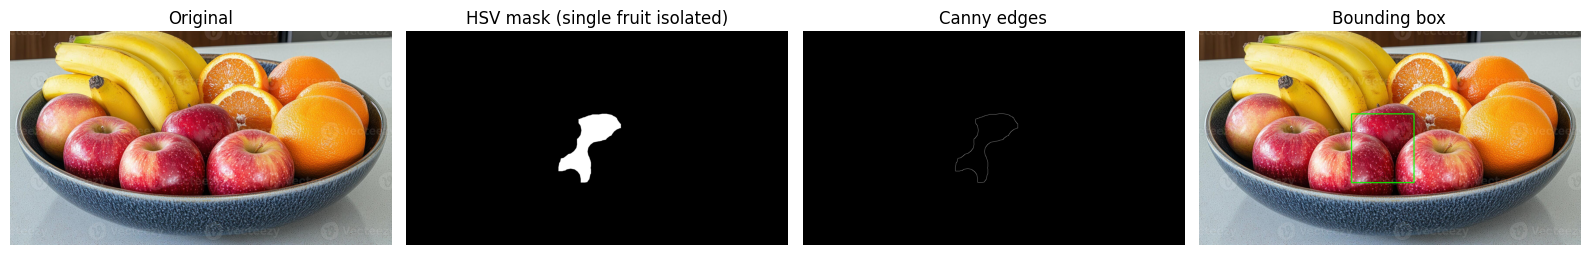

Saved: /content/assignment_images/q14_pipeline_red_apple_1.jpg
Q14 output saved to: /content/assignment_images/q14_pipeline_red_apple_1.jpg
Bounding box: x=698, y=379, w=286, h=315


In [38]:
# Q14 — Full pipeline: one fruit from mixed_fruit_bowl.jpeg -> load -> BGR/RGB -> HSV mask ->
# morph cleanup -> Canny -> bbox -> safe_imwrite()

TARGET_FRUIT = "red_apple.jpg"          # which fruit's HSV range to isolate from the bowl
TARGET_RANGES = BOWL_HSV_RANGES[TARGET_FRUIT]  # bowl-measured ranges, not the Fruits-360 dict

# 1. Load
bowl_bgr = cv2.imread(os.path.join(OUT_DIR, "mixed_bowl.jpg"))
bowl_rgb = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2RGB)

# 2. HSV mask
bowl_hsv = cv2.cvtColor(bowl_bgr, cv2.COLOR_BGR2HSV)
fruit_mask = build_mask(bowl_hsv, TARGET_RANGES)

# 3. Morphological cleanup
kernel = np.ones((7, 7), np.uint8)
clean_mask = cv2.morphologyEx(fruit_mask, cv2.MORPH_OPEN, kernel)
clean_mask = cv2.morphologyEx(clean_mask, cv2.MORPH_CLOSE, kernel)

# 3b. Separate touching same-color fruit before picking "one". In this photo the apples sit
# pressed together, so the HSV mask alone comes back as a single blob spanning all of them
# (confirmed while building this: largest-contour-on-the-raw-mask gave one box covering all
# 5 apples). Distance transform + connected components on the local peaks recovers individual
# fruit centers even when their masks touch.
dist = cv2.distanceTransform(clean_mask, cv2.DIST_L2, 5)
_, sure_fg = cv2.threshold(dist, 0.5 * dist.max(), 255, 0)
sure_fg = sure_fg.astype(np.uint8)
n_peaks, peak_labels = cv2.connectedComponents(sure_fg)

if n_peaks > 1:
    # pick the largest peak blob as "the one fruit", then dilate back out to its full extent
    best_label = max(range(1, n_peaks), key=lambda lbl: (peak_labels == lbl).sum())
    single_fruit_mask = np.uint8(peak_labels == best_label) * 255
    single_fruit_mask = cv2.dilate(single_fruit_mask, kernel, iterations=3)
    single_fruit_mask = cv2.bitwise_and(single_fruit_mask, clean_mask)
else:
    single_fruit_mask = clean_mask  # only one blob to begin with, no separation needed

# 4. Canny on the isolated single-fruit mask
edges = cv2.Canny(single_fruit_mask, 50, 150)

# 5. Bounding box from the isolated fruit's contour
contours, _ = cv2.findContours(single_fruit_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
bbox_img = bowl_bgr.copy()
if contours:
    largest = max(contours, key=cv2.contourArea)
    x, y, w, h = cv2.boundingRect(largest)
    cv2.rectangle(bbox_img, (x, y), (x + w, y + h), (0, 255, 0), 4)
else:
    x = y = w = h = None
    print("No contour found for", TARGET_FRUIT, "- check HSV range against the bowl image.")

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(bowl_rgb); axes[0].set_title("Original"); axes[0].axis("off")
axes[1].imshow(single_fruit_mask, cmap="gray"); axes[1].set_title("HSV mask (single fruit isolated)"); axes[1].axis("off")
axes[2].imshow(edges, cmap="gray"); axes[2].set_title("Canny edges"); axes[2].axis("off")
axes[3].imshow(cv2.cvtColor(bbox_img, cv2.COLOR_BGR2RGB)); axes[3].set_title("Bounding box"); axes[3].axis("off")
plt.tight_layout()
plt.show()

# 6. Save via safe_imwrite (defined earlier in the Colab setup section)
saved_path = safe_imwrite(os.path.join(OUT_DIR, f"q14_pipeline_{TARGET_FRUIT}"), bbox_img)
print("Q14 output saved to:", saved_path)
if x is not None:
    print(f"Bounding box: x={x}, y={y}, w={w}, h={h}")